# Modelo 7_6 pero agrupando todo lo que no es clase 1 en una sola clase

In [3]:
version = "7_6"

In [4]:
import pickle
import pandas as pd
import numpy as np
import json

pd.set_option("display.max_rows", None)   # Muestra todas las filas
pd.set_option("display.max_columns", None)  # Muestra todas las columnas
pd.set_option("display.width", None)     # No corta la tabla en varias líneas
pd.set_option("display.max_colwidth", None)  # Muestra el contenido de celdas completo

In [5]:
# with open("../../data/normalized/df_normalized.pk1", "rb") as f:
with open("../../data/normalized/df_normalized_dayOfYear.pk1", "rb") as f:
    df_data = pickle.load(f)

In [6]:
# Se redonde al minuto mas cercano
df_data["started_minute"] = df_data["started_at"].dt.round("min")

In [7]:
df_agg = df_data.groupby([
    "start_station_idx",
    "end_station_idx",
    "started_minute"
]).agg(
    n_viajes=("ride_id", "count"),
    year=("year", "first"),
    temp_std=("temp_std", "first"),
    wind_std=("wind_std", "first"),
    rel_humidity_std=("rel_humidity_std", "first"),
    precipitation_std=("precipitation_std", "first"),
    snow_depth_std=("snow_depth_std", "first"),
    hour_sin=("hour_sin", "first"),
    hour_cos=("hour_cos", "first"),
    month_sin=("month_sin", "first"),
    month_cos=("month_cos", "first"),
    event=("event", "any"),  # True si al menos un dato es true
    normal_day=("day_type_Normal", "any"),  # True si al menos un dato es true
    weekend_day=("day_type_Weekend", "any"),  # True si al menos un dato es true
    holiday_day=("day_type_Holiday", "any"),  # True si al menos un dato es true
    doy_sin=("doy_sin", "first"),
    doy_cos=("doy_cos", "first"),
    #member_casual=("member_casual_bool", "any"),  # True si al menos un dato es true
    #classic_bike=("rideable_type_classic_bike", "any"),  # True si al menos un dato es true
    #docked_bike=("rideable_type_docked_bike", "any"),  # True si al menos un dato es true
    #electric_bike=("rideable_type_electric_bike", "any"),  # True si al menos un dato es true
    #duration_min_mean=("duration_min", "mean"),
).reset_index()

# Se divide la cantidad de viajes 1 en varias subclases

In [8]:
df_class_1 = df_agg[df_agg['n_viajes'] == 1]

In [9]:
with open("../../data/normalized/le_station_encoder.pkl", "rb") as f:
    le_station = pickle.load(f)
    
num_stations = len(le_station.classes_)

In [10]:
df_class_1 = df_agg[df_agg['n_viajes'] == 1].copy()

def assign_subclass(row):
    if row['start_station_idx'] < (num_stations / 2):
        return 1  # Estaciones "bajas"
    else:
        # Estaciones "altas", subdividir por hora
        h = row['started_minute'].hour
        if h <= 10:
            return 2
        elif h <= 17:
            return 3
        else:
            return 4

df_agg.loc[df_class_1.index, 'subclass'] = df_class_1.apply(assign_subclass, axis=1)

# Revisar conteo por subclase
print(df_agg['subclass'].value_counts())


subclass
3.0    4163596
4.0    2190680
2.0    2172307
1.0     144874
Name: count, dtype: int64


In [ ]:
mask = df_agg['n_viajes'] > 1
df_agg.loc[mask, 'subclass'] = df_agg.loc[mask, 'n_viajes'] + 3

# Revisar conteo por subclase
print(df_agg['subclass'].value_counts())

subclass
3.0     4163596
4.0     2190680
2.0     2172307
5.0      372173
1.0      144874
6.0       24990
7.0        4098
8.0         565
9.0         103
10.0         19
11.0          4
12.0          1
Name: count, dtype: int64


: 

: 

: 

: 

: 

: 

Se agrupan los viajes de más de una unidad en una única clase

In [ ]:
mask = df_agg['subclass'] >= 5
df_agg.loc[mask, 'subclass'] = 5

# Revisar conteo por subclase
print(df_agg['subclass'].value_counts())

subclass
3.0    4163596
4.0    2190680
2.0    2172307
5.0     401953
1.0     144874
Name: count, dtype: int64


: 

: 

: 

: 

: 

: 

In [ ]:
# convertir a entero
df_agg['subclass'] = df_agg['subclass'].astype(int)

: 

: 

: 

: 

: 

: 

# Simulacion de datos con SMOT de las clases minoritarias

Se intenta no igualar las clases porque no tendría sentido en clases tan desvalanceadas

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from collections import Counter

# --- 1. Separar features y target ---
df = df_agg.copy()

data_raw = df.drop(columns=['started_minute'])  # quitar datetime
y = df['subclass'].astype(int)

print("Antes:", Counter(y))

# --- 3. Ajustar estrategia SMOTE ---
# Como tus clases 7 y 8 tienen muy pocos ejemplos,
# usamos k_neighbors=2 y fijamos targets razonables.

target_sizes = {
    1: 150_000,
    6: 40_000,
    7: 10_000,
    8: 5_000
}

sm = SMOTE(
    sampling_strategy=target_sizes,
    k_neighbors=2,
    random_state=42
)

# --- 4. Aplicar SMOTE ---
data_smote, y_smote = sm.fit_resample(data_raw, y)

print("Después:", Counter(y_smote))

# 4. Reconstruir DataFrame final
df_smote = pd.DataFrame(data_smote, columns=df_agg.columns.drop("started_minute"))
df_smote['subclass'] = y_smote


: 

: 

: 

: 

: 

: 

In [ ]:
# Revisar conteo por subclase
print(df_smote['subclass'].value_counts())

: 

: 

: 

: 

: 

: 

# Obtención de los datos

In [ ]:
df_smote = df_agg.copy()
df_smote = df_smote.drop(columns=['started_minute'])  # quitar datetime

: 

: 

: 

: 

: 

: 

In [ ]:
x_context = df_smote.drop(columns=[
    "n_viajes",
    #"started_minute",
    "start_station_idx",
    "end_station_idx",
    "subclass",
])

x_start = df_smote[[
    "start_station_idx",
]]

x_end = df_smote[[
    "end_station_idx",
]]

y = df_smote["subclass"]

: 

: 

: 

: 

: 

: 

In [ ]:
x_context.head()

,year,temp_std,wind_std,rel_humidity_std,precipitation_std,snow_depth_std,hour_sin,hour_cos,month_sin,month_cos,event,normal_day,weekend_day,holiday_day,doy_sin,doy_cos
0,2022,-1.379839,1.021427,1.326397,-0.099704,-0.056148,-0.416215,-0.909266,0.500000,0.866025,False,False,False,True,0.661635,0.749826
1,2022,-0.612834,-0.276355,-0.807078,-0.099704,-0.056148,-0.717569,-0.696487,0.866025,0.500000,False,False,True,False,0.891981,0.452072
2,2022,-1.156238,4.113864,0.687365,-0.099704,-0.056148,0.281155,-0.959662,0.866025,0.500000,False,False,True,False,0.899631,0.436651
3,2022,-0.424108,-0.883141,-1.019270,-0.099704,-0.056148,-0.972183,-0.234223,0.866025,0.500000,False,False,True,False,0.977848,0.209315
4,2022,-0.410327,-0.825775,-1.038403,-0.099704,-0.056148,-0.976781,-0.214238,0.866025,0.500000,False,False,True,False,0.977848,0.209315


: 

: 

: 

: 

: 

: 

# Se continua diviendo los datos

In [ ]:
with open("../../data/normalized/le_station_encoder.pkl", "rb") as f:
    le_station = pickle.load(f)
    
len(le_station.classes_)

1912

: 

: 

: 

: 

: 

: 

In [ ]:
# El target empieza en 1 → lo pasamos a 0
y_cls = y - 1

num_classes = y_cls.max() + 1
print("Clases totales:", num_classes)

Clases totales: 5


: 

: 

: 

: 

: 

: 

In [ ]:
from sklearn.model_selection import train_test_split

x_ctx_train, x_ctx_test, x_start_train, x_start_test, x_end_train, x_end_test, y_train, y_test = \
    train_test_split(x_context, x_start, x_end, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

x_ctx_train, x_ctx_val, x_start_train, x_start_val, x_end_train, x_end_val, y_train, y_val = \
    train_test_split(x_ctx_train, x_start_train, x_end_train, y_train, test_size=0.2, random_state=42, stratify=y_train)


: 

: 

: 

: 

: 

: 

# Se calculan los pesos

In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

classes_present = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes_present,
    y=y_train
)

class_weights = {i: w for i, w in zip(classes_present, class_weights)}
print(class_weights)


{np.int64(0): np.float64(12.525980651214962), np.int64(1): np.float64(0.8353705053021808), np.int64(2): np.float64(0.43584492218826804), np.int64(3): np.float64(0.8283647697810682), np.int64(4): np.float64(4.514660447035957)}


: 

: 

: 

: 

: 

: 

In [ ]:
print("Clases en train:", np.unique(y_train))
print("Clases totales:", np.arange(num_classes))


Clases en train: [0 1 2 3 4]
Clases totales: [0 1 2 3 4]


: 

: 

: 

: 

: 

: 

# Creación del modelo

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input, regularizers
from tensorflow.keras.optimizers import Adam
import numpy as np

#    --- INTENTO DE METRICA PERSONALIZADA ---
# GRUPO_PASA_M2 = tf.constant([0,1,2,3], dtype=tf.int64)

# class RecallGrupoPasaM2(tf.keras.metrics.Metric):
#     def __init__(self, name="recall_grupo_pasa_m2", **kwargs):
#         super().__init__(name=name, **kwargs)
#         self.tp = self.add_weight(name="tp", initializer="zeros")
#         self.fn = self.add_weight(name="fn", initializer="zeros")

#     def update_state(self, y_true, y_pred, sample_weight=None):
#         y_pred = tf.argmax(y_pred, axis=1)
#         y_true = tf.cast(y_true, tf.int64)

#         y_true_pos = tf.reduce_any(
#             tf.equal(y_true[..., None], GRUPO_PASA_M2), axis=-1
#         )
#         y_pred_pos = tf.reduce_any(
#             tf.equal(y_pred[..., None], GRUPO_PASA_M2), axis=-1
#         )

#         tp = tf.logical_and(y_true_pos, y_pred_pos)
#         fn = tf.logical_and(y_true_pos, tf.logical_not(y_pred_pos))

#         self.tp.assign_add(tf.reduce_sum(tf.cast(tp, tf.float32)))
#         self.fn.assign_add(tf.reduce_sum(tf.cast(fn, tf.float32)))

#     def result(self):
#         return self.tp / (self.tp + self.fn + 1e-7)

#     def reset_state(self):
#         self.tp.assign(0)
#         self.fn.assign(0)

# class PrecisionGrupoPasaM2(tf.keras.metrics.Metric):
#     def __init__(self, name="precision_grupo_pasa_m2", **kwargs):
#         super().__init__(name=name, **kwargs)
#         self.tp = self.add_weight(name="tp", initializer="zeros")
#         self.fp = self.add_weight(name="fp", initializer="zeros")

#     def update_state(self, y_true, y_pred, sample_weight=None):
#         y_pred = tf.argmax(y_pred, axis=1)
#         y_true = tf.cast(y_true, tf.int64)

#         y_true_pos = tf.reduce_any(
#             tf.equal(y_true[..., None], GRUPO_PASA_M2), axis=-1
#         )
#         y_pred_pos = tf.reduce_any(
#             tf.equal(y_pred[..., None], GRUPO_PASA_M2), axis=-1
#         )

#         tp = tf.logical_and(y_true_pos, y_pred_pos)
#         fp = tf.logical_and(tf.logical_not(y_true_pos), y_pred_pos)

#         self.tp.assign_add(tf.reduce_sum(tf.cast(tp, tf.float32)))
#         self.fp.assign_add(tf.reduce_sum(tf.cast(fp, tf.float32)))

#     def result(self):
#         return self.tp / (self.tp + self.fp + 1e-7)

#     def reset_state(self):
#         self.tp.assign(0)
#         self.fp.assign(0)



num_stations = len(le_station.classes_)
num_features = x_context.shape[1]

l2_reg = 1e-4
drop_rate = 0.3

# Inputs
input_start = Input(shape=(1,), name='start_station')
input_end = Input(shape=(1,), name='end_station')
input_context = Input(shape=(num_features,), name='context')

# Embeddings
embed_dim = int(np.ceil(np.sqrt(num_stations)))
embed_start = layers.Embedding(num_stations, embed_dim,embeddings_regularizer=regularizers.l2(l2_reg))(input_start)
embed_end = layers.Embedding(num_stations, embed_dim,embeddings_regularizer=regularizers.l2(l2_reg))(input_end)

# Flatten
flat_start = layers.Flatten()(embed_start)
flat_end = layers.Flatten()(embed_end)

# Concatenate
x = layers.Concatenate()([flat_start, flat_end, input_context])

# Dense Block 1
x = layers.Dense(128,kernel_regularizer=regularizers.l2(l2_reg))(x)
#x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)
x = layers.Dropout(drop_rate)(x)

# Dense Block 2
x = layers.Dense(64,kernel_regularizer=regularizers.l2(l2_reg))(x)
#x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)
x = layers.Dropout(drop_rate)(x)

# Dense Block 3
x = layers.Dense(32,kernel_regularizer=regularizers.l2(l2_reg))(x)
#x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)
x = layers.Dropout(drop_rate)(x)

# Output
output = layers.Dense(num_classes, activation='softmax')(x)

# Model
model = Model(inputs=[input_start, input_end, input_context], outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# model.compile(
#     optimizer=Adam(learning_rate=1e-4),
#     loss="sparse_categorical_crossentropy",
#     metrics=[
#         "accuracy",                     # informativa
#         RecallGrupoPasaM2(),             # MÉTRICA OBJETIVO
#         PrecisionGrupoPasaM2()           # control de ruido
#     ]
# )

model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ start_station       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ end_station         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_8         │ (None, 1, 44)     │     84,128 │ start_station[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_9         │ (None, 1, 44)     │     84,128 │ end_station[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_8 (Flatten) │ (None, 44)        │          0 │ embedding_8[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_9 (Flatten) │ (None, 44)        │          0 │ embedding_9[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context             │ (None, 16)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 104)       │          0 │ flatten_8[0][0],  │
│ (Concatenate)       │                   │            │ flatten_9[0][0],  │
│                     │                   │            │ context[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 128)       │     13,440 │ concatenate_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_12      │ (None, 128)       │          0 │ dense_16[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 128)       │          0 │ leaky_re_lu_12[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 64)        │      8,256 │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_13      │ (None, 64)        │          0 │ dense_17[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 64)        │          0 │ leaky_re_lu_13[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 32)        │      2,080 │ dropout_13[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_14      │ (None, 32)        │          0 │ dense_18[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 32)        │          0 │ leaky_re_lu_14[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 5)         │        165 │ dropout_14[0][0]  │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 192,197 (750.77 KB)

 Trainable params: 192,197 (750.77 KB)

 Non-trainable params: 0 (0.00 B)

...

: 

: 

: 

: 

: 

In [ ]:
%%time
# Entrenamiento
history = model.fit(
    {'start_station': x_start_train, 'end_station': x_end_train, 'context': x_ctx_train},
    y_train,
    validation_data=(
        {'start_station': x_start_val, 'end_station': x_end_val, 'context': x_ctx_val},
        y_val
    ),    
    batch_size=256,
    epochs=50,
    class_weight=class_weights,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )
    ]
)

# %%time
# # Entrenamiento
# history = model.fit(
#     {'start_station': x_start_train, 'end_station': x_end_train, 'context': x_ctx_train},
#     y_train,
#     validation_data=(
#         {'start_station': x_start_val, 'end_station': x_end_val, 'context': x_ctx_val},
#         y_val
#     ),    
#     batch_size=256,
#     epochs=50,
#     class_weight=class_weights,
#     callbacks=[
#         tf.keras.callbacks.EarlyStopping(
#             monitor="val_recall_grupo_pasa_m2",
#             patience=5,
#             mode='max',
#             restore_best_weights=True
#         )
#     ]
# )


Epoch 1/50
22684/22684 ━━━━━━━━━━━━━━━━━━━━ 71s 3ms/step - accuracy: 0.6112 - loss: 5.4430 - val_accuracy: 0.9070 - val_loss: 0.4143
Epoch 2/50
22684/22684 ━━━━━━━━━━━━━━━━━━━━ 85s 4ms/step - accuracy: 0.8481 - loss: 0.5328 - val_accuracy: 0.8634 - val_loss: 0.4365
Epoch 3/50
22684/22684 ━━━━━━━━━━━━━━━━━━━━ 64s 3ms/step - accuracy: 0.8583 - loss: 0.5124 - val_accuracy: 0.8449 - val_loss: 0.4885
Epoch 4/50
22684/22684 ━━━━━━━━━━━━━━━━━━━━ 66s 3ms/step - accuracy: 0.8633 - loss: 0.5029 - val_accuracy: 0.9076 - val_loss: 0.4003
Epoch 5/50
22684/22684 ━━━━━━━━━━━━━━━━━━━━ 78s 3ms/step - accuracy: 0.8654 - loss: 0.4983 - val_accuracy: 0.8918 - val_loss: 0.3718
Epoch 6/50
22684/22684 ━━━━━━━━━━━━━━━━━━━━ 70s 3ms/step - accuracy: 0.8656 - loss: 0.4940 - val_accuracy: 0.9176 - val_loss: 0.3656
Epoch 7/50
22684/22684 ━━━━━━━━━━━━━━━━━━━━ 69s 3ms/step - accuracy: 0.8663 - loss: 0.4903 - val_accuracy: 0.8763 - val_loss: 0.3806
Epoch 8/50
22684/22684 ━━━━━━━━━━━━━━━━━━━━ 55s 2ms/step - accuracy: 

: 

: 

: 

: 

: 

: 

In [ ]:
import matplotlib.pyplot as plt

def show_history(history, model_name: str):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10))  # 2 filas, 1 columna

    # Pérdida (loss)
    ax1.plot(history.history['loss'],     label='Training Loss',  color='green')
    ax1.plot(history.history['val_loss'], label='Validation Loss', color='blue')
    ax1.set_title('Loss evolution')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # Precisión (accuracy)
    ax2.plot(history.history['accuracy'],     label='Training Accuracy',  color='green')
    ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')
    ax2.set_title('Accuracy evolution')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    # Título global
    fig.suptitle(model_name, fontsize=16)

    # Ajustar márgenes
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

: 

: 

: 

: 

: 

: 

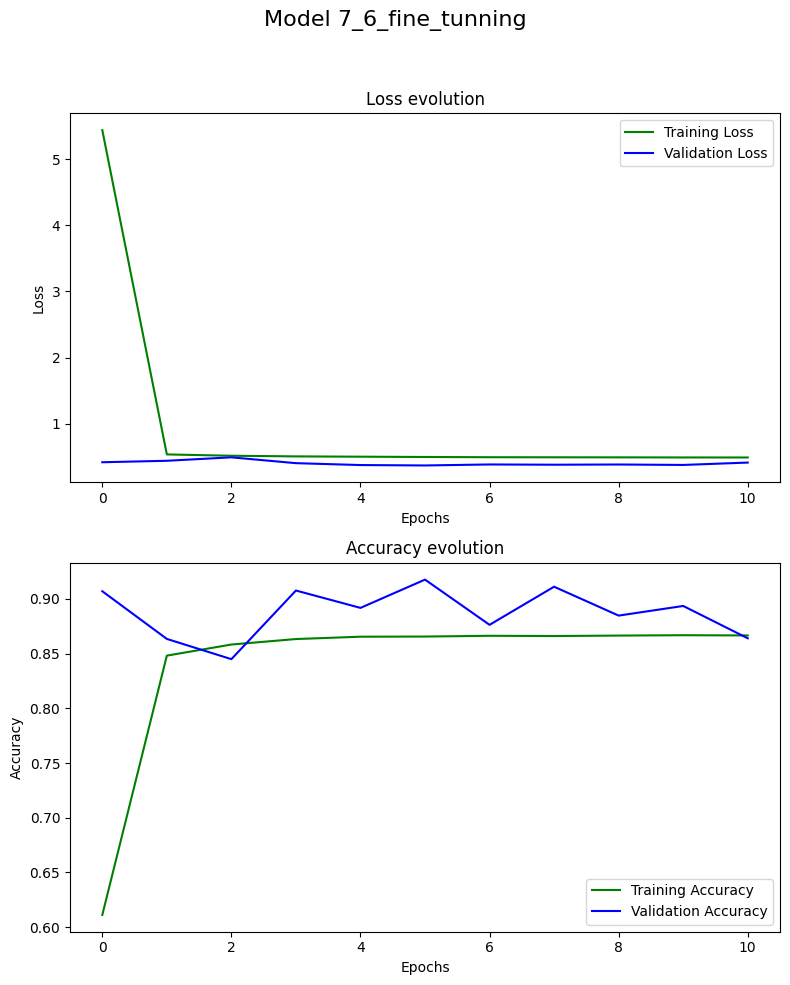

: 

: 

: 

: 

: 

: 

In [ ]:
show_history(history, f"Model {version}")

In [ ]:
model.save(f"model_{version}.keras")

with open(f'history_{version}.json', 'w') as f:
    json.dump(history.history, f)

AttributeError: 'dict' object has no attribute 'history'

: 

: 

: 

: 

: 

: 

In [ ]:
with open(f'history_{version}.json', "r", encoding="utf-8") as f:
    history = json.load(f)
    
# Mejor época según val_accuracy
best_epoch = np.argmin(history['val_loss'])
best_train_acc = history['accuracy'][best_epoch]
best_val_acc = history['val_accuracy'][best_epoch]
best_val_loss = history['val_loss'][best_epoch]

print("Mejor época:", best_epoch+1)
print("Mejor train_accuracy:", best_train_acc)
print("Mejor val_accuracy:", best_val_acc)
print("Mejor val_loss:", best_val_loss)

Mejor época: 10
Mejor train_accuracy: 0.8663282990455627
Mejor val_accuracy: 0.9226118326187134
Mejor val_loss: 0.3415754437446594


: 

: 

: 

: 

: 

: 

# Evaluar modelo

In [ ]:
# ---------- Evaluación final sobre el test set real
test_metrics = model.evaluate(
    {'start_station': x_start_test, 'end_station': x_end_test, 'context': x_ctx_test},
    y_test,
    verbose=2
)
print("Test metrics (loss, accuracy):", test_metrics)

56709/56709 - 47s - 826us/step - accuracy: 0.9173 - loss: 0.3659
Test metrics (loss, accuracy): [0.36592328548431396, 0.9172813892364502]


: 

: 

: 

: 

: 

: 

# Predicción modelo

In [ ]:
from tensorflow.keras.models import load_model

model = load_model(f"model_{version}.keras")

: 

: 

: 

: 

: 

: 

In [ ]:
# Predicciones como probabilidades
y_pred_probs = model.predict({
    'start_station': x_start,
    'end_station': x_end,
    'context': x_context
}, batch_size=256)

print("Shape de predicciones:", y_pred_probs.shape)
# (num_ejemplos, num_classes)


35444/35444 ━━━━━━━━━━━━━━━━━━━━ 30s 833us/step
Shape de predicciones: (9073410, 5)


: 

: 

: 

: 

: 

: 

In [ ]:
# Elegimos la clase con mayor probabilidad



y_pred_classes = np.argmax(y_pred_probs, axis=1)

print("Clases predichas:", np.unique(y_pred_classes))

Clases predichas: [0 1 2 3 4]


: 

: 

: 

: 

: 

: 

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy
acc = accuracy_score(y_cls, y_pred_classes)
print("Accuracy test:", acc)

# Reporte detallado por clase
print(classification_report(y_cls, y_pred_classes))

# Matriz de confusión
cm = confusion_matrix(y_cls, y_pred_classes)
print(cm)


Accuracy test: 0.9224486714476696
              precision    recall  f1-score   support

           0       0.97      1.00      0.99    144874
           1       0.97      0.99      0.98   2172307
           2       0.95      0.94      0.94   4163596
           3       0.94      0.97      0.95   2190680
           4       0.12      0.10      0.11    401953

    accuracy                           0.92   9073410
   macro avg       0.79      0.80      0.80   9073410
weighted avg       0.92      0.92      0.92   9073410

[[ 144816       0      19       1      38]
 [     29 2152756    2027    2907   14588]
 [     30    6643 3909597    1619  245707]
 [     21    1942   30292 2121653   36772]
 [   4056   51468  172716  132780   40933]]


: 

: 

: 

: 

: 

: 

# Se elimina la extensión de la categoría 1

In [ ]:
y_cls.unique()

array([0, 4, 2, 3, 1])

: 

: 

: 

: 

: 

: 

In [ ]:
np.unique(y_pred_classes)

array([0, 1, 2, 3, 4])

: 

: 

: 

: 

: 

: 

In [ ]:
conteo_clases = y_cls.value_counts()
print(conteo_clases)

subclass
2    4163596
3    2190680
1    2172307
4     401953
0     144874
Name: count, dtype: int64


: 

: 

: 

: 

: 

: 

In [ ]:
mapping = {
    0: 1,
    1: 1,
    2: 1,
    3: 1,
    4: 2
}

y_cls_real = y_cls.map(mapping)
y_pred_real = np.vectorize(lambda x: mapping.get(x, x))(y_pred_classes)

print(np.unique(y_pred_real))
print(y_cls_real.unique())


[1 2]
[1 2]


: 

: 

: 

: 

: 

: 

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy
acc = accuracy_score(y_cls_real, y_pred_real)
print("Accuracy test:", acc)

# Reporte detallado por clase
print(classification_report(y_cls_real, y_pred_real))

# Matriz de confusión
cm = confusion_matrix(y_cls_real, y_pred_real)
print(cm)

Accuracy test: 0.9274666305170823
              precision    recall  f1-score   support

           1       0.96      0.97      0.96   8671457
           2       0.12      0.10      0.11    401953

    accuracy                           0.93   9073410
   macro avg       0.54      0.53      0.54   9073410
weighted avg       0.92      0.93      0.92   9073410

[[8374352  297105]
 [ 361020   40933]]


: 

: 

: 

: 

: 

: 

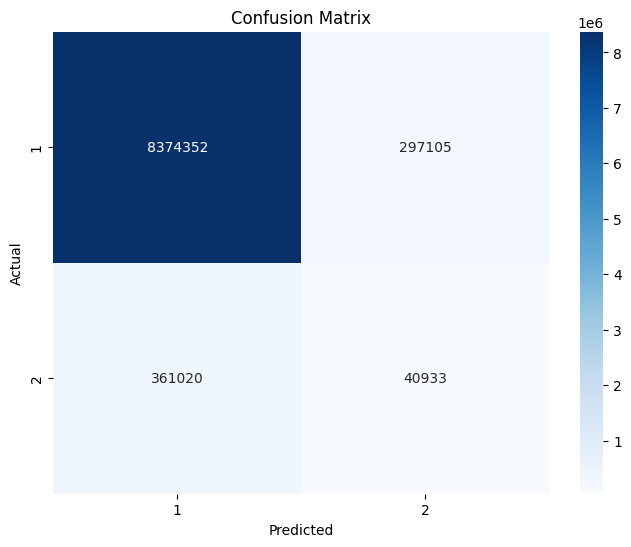

: 

: 

: 

: 

: 

: 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualización con heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=set(y_cls_real), yticklabels=set(y_cls_real))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

: 

: 

: 

: 

: 

: 